# Машинное обучение, ФКН ВШЭ

# Практическое задание 13. Рекомендательные системы

## Общая информация
**Дата выдачи: 01.06.2025**

**Мягкий дедлайн: 14.06.2025 23:59 MSK**

**Жёсткий дедлайн: 16.06.2025 23:59 MSK**

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — **11** баллов + **2.5** бонусных.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-13-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этой работе мы будем решать задачу рекомендации музыки. То есть мы поставим целью получить модель, которая для каждого пользователя будет возвращать набор треков, наиболее похожих на те, что он уже слушал. В первой части мы разберемся с memory-based подходом и моделью со скрытыми переменными. Это не очень мощные методы, но зато они позволяют строить предсказания почти моментально. Затем, во второй части, мы обратим внимание на то, что датасет содержит огромное число треков и воспользуемся результатами уже построенных быстрых моделей для сокращения списка кандидатов до разумного количества. После этого проведем ранжирование среди кандидатов с помощью сильной, но чуть более медленной модели, и отберем самые лучшие варианты. Такой двухэтапный алгоритм построения рекомендаций изображен на картинке.


![photo_2023-05-17%2020.06.18.jpeg](attachment:photo_2023-05-17%2020.06.18.jpeg)

In [2]:
import warnings
warnings.filterwarnings('ignore')

Приступим!

Все шаблоны ниже можно переписывать по своему усмотрению.

In [3]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

In [4]:
ratings = pd.read_csv('https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2025-spring/homeworks-practice/homework-practice-13-recommendations/music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [5]:
tracks_info = pd.read_csv('https://raw.githubusercontent.com/esokolov/ml-course-hse/refs/heads/master/2025-spring/homeworks-practice/homework-practice-13-recommendations/tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

**Задание 1 (0.5 балл).** Реализуйте метрику $MAP@k$.

In [6]:
def mapk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20):
  return np.mean([apk(r, p, k) for r, p in zip(relevant, predicted)])

def apk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20):
  r = np.isin(predicted[:k], relevant)
  p = np.cumsum(r) / (np.arange(1, len(r) + 1))
  return (r * p).sum() / min(len(relevant), k)

In [7]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [8]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    # getting train samples
    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [9]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [10]:
train_ratings

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404
...,...,...
129399,240,68218
129400,240,68236
129401,240,68304
129402,240,68362


In [11]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [12]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [13]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

Соберем все релевантные треки для каждого пользователя в список.

In [14]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

**Задание 2 (0.5 балла).** Реализуйте метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Не забывайте удалять уже прослушанные треки из рекомендуемых.

In [15]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items)) # юзер слушал трек i - матрица взаимодействий в общем
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.

    def recommend(self, uid: int): # заглушка - самый популярный трек
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        scores = np.sum(self.R, axis=0)
        return np.argsort(-scores)

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]
        return new_preds

    def get_test_recommendations(self, k: int):
        full_preds = [self.recommend(uid) for uid in range(self.n_users)]
        full_preds = self.remove_train_items(full_preds, k)
        return full_preds[np.array(test_users)]

In [16]:
# model = BaseModel(train_ratings)
# model.get_test_recommendations(k=2)

### Часть 1. Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать меру Жаккара:

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Во всех формулах
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

**Задание 3.2 (0.5 балла).** Реализуйте функцию подсчета меры Жаккара.

Функция принимает матрицу оценок и вектор оценок пользователя $u$ и возвращает вектор со значениями похожести пользователя $u$ на всех пользователей. Старайтесь писать оптимизированный код, за неэффективную реализацию оценка может быть снижена.

In [17]:
def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    ratings = ratings.astype(bool)
    user_vector = user_vector.astype(bool)

    a = np.sum(ratings&user_vector, axis=1)
    b = np.sum(ratings|user_vector, axis=1)
    return a/b # деление на 0 тут???

**Задание 4 (1 балл).** Реализуйте методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные в порядке убывания предсказанных оценок. Значение парамметра `alpha` можно менять по своему усмотрению так, чтобы оно было разумным.

In [18]:
class User2User(BaseModel):
    def __init__(self, ratings):
        super().__init__(ratings)

        self.similarity_func = jaccard
        self.alpha = 0.02
        self.sims = None

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """
        return self.similarity_func(self.R, user_vector)

    def recommend(self, uid: int):
        user_vector = self.R[uid]
        self.sims = self.similarity(user_vector) # передаем user_vector
        neighbours = np.where(self.sims>self.alpha)[0] # тут индексы соседей для user_vector
        neighbours = neighbours[neighbours!=uid] # убираем юзера из соседей

        if len(neighbours) == 0:
            # Если нет похожих — fallback: вернуть топ-популярные
            return np.argsort(-self.R.sum(axis=0))

        scores = self.sims[neighbours]@self.R[neighbours]

        return np.argsort(-scores)

In [19]:
# RRR = model.R
# n_items = 67313
# uid = 0
# alpha = 0.02
# r_v = RRR[uid]
# sims = jaccard(RRR, r_v)
# neighbours = np.where(sims>alpha)[0]
# neighbours = neighbours[neighbours!=uid]

# scores = sims[neighbours]@RRR[neighbours]
# # np.sum(RRR[neighbours]*sims[neighbours].reshape(-1,1), axis = 0)
# np.argsort(-scores)

**Задание 5 (0.5 балл).** Постройте график зависимости значений $MAP@k$ от разных $k$ при рекомендации на основе меры Жаккара, сравните его с рекомендициями самых популярных треков и случайных. Какой из трех способов рекомендаций оказался лучшим?

In [20]:
user2user = User2User(train_ratings)
mostpopular = BaseModel(train_ratings)

class RandomModel(BaseModel):
    def recommend(self, uid: int):
        return np.random.permutation(self.n_items)

random_model = RandomModel(train_ratings)

In [21]:
K_MAX = 20
pred_user2user = user2user.get_test_recommendations(k=K_MAX)
pred_popular = mostpopular.get_test_recommendations(k=K_MAX)
pred_random = random_model.get_test_recommendations(k=K_MAX)

In [22]:
ks = list(range(1, K_MAX + 1))
map_u2u, map_pop, map_rand = [], [], []

for k in ks:
    map_u2u.append(mapk(test_relevant, pred_user2user[:, :k], k))
    map_pop.append(mapk(test_relevant, pred_popular[:, :k], k))
    map_rand.append(mapk(test_relevant, pred_random[:, :k], k))

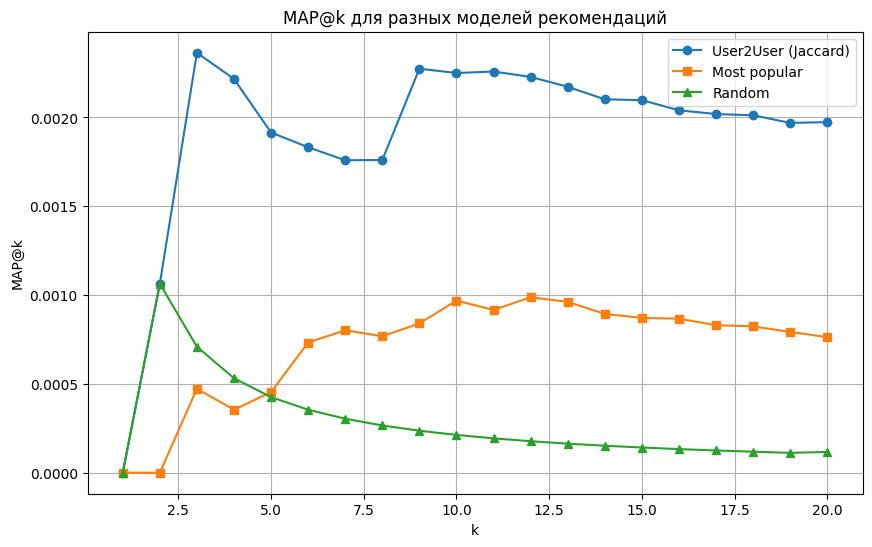

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(ks, map_u2u, label='User2User (Jaccard)', marker='o')
plt.plot(ks, map_pop, label='Most popular', marker='s')
plt.plot(ks, map_rand, label='Random', marker='^')

plt.xlabel('k')
plt.ylabel('MAP@k')
plt.title('MAP@k для разных моделей рекомендаций')
plt.grid(True)
plt.legend()
plt.show()


1. User2User (Jaccard) дает наилучшие значения метрики на всем диапазоне k

*   Особенно хорошо работает для случаев с малым k (до 5 примерно), а дальше наблюдается некоторая временная просадка.

2. Most Popular подход: в принципе ок, но весьма просто и можно что-то более интересное придумать
*   Лучше случайного, но хуже персонализированных рекомендаций
*   Схожесть формы кривой с User2User может говорить о том, что популярные треки влияют на вкусы пользователей
3. Random подход: ну тут хз, все очень не очень, что и следовало ожидать....

**Бонус (1 балла).** Как вы могли заметить, матрица оценок получается очень разреженной, но мы работаем с ней как с обычной, это не дело. Перепишите код так, чтобы все методы могли работать с разреженными матрицами и сравните скорость работы такого подхода с оригинальным.

Мы можем посмотреть глазами, насколько хорошо модель рекомендует треки. Для этого сравним уже прослушанные треки с рекомендованными и релевантными для случайного пользователя. Хорошо ли у вас получилось?

In [24]:
user_id = np.random.randint(0, user2user.n_users)

In [25]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
94,Iron Man,['Black Sabbath']
95,Paranoid,['Black Sabbath']
118,Pages,['3 Doors Down']
135,You Know My Name,['Chris Cornell']
164,My Favourite Game,['The Cardigans']
205,The Bleeding,['Five Finger Death Punch']
234,Wind Of Change,['Scorpions']
238,The Call Of Ktulu,['Metallica']
239,Master Of Puppets,['Metallica']
276,You're All I Have,['Snow Patrol']


In [26]:
preds = user2user.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

Predicted tracks:


,name,artists
24500,Way Down We Go,['KALEO']
35656,I Got Love,"['Miyagi & Эндшпиль', 'Рем Дигга']"
49704,Девочка-война,['HammAli & Navai']
46279,"Мама, я танцую",['#2Маши']
59117,Кометы,['polnalyubvi']
42937,Малиновый свет,['Лёша Свик']
61675,Coco L'Eau,"['ЕГОР КРИД', 'The Limba']"
27516,Ты словно целая вселенная,['Jah Khalib']
57338,Kosandra,['Miyagi & Andy Panda']
30578,Люби меня,"['Miyagi & Эндшпиль', 'Sимптом']"


In [27]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
57047,T.I.N.A.,['Enter Shikari']
60610,Электричество,['Lumen']
60689,Время выбирать,['АУТКАСТ']
61728,Obey,"['Bring Me The Horizon', 'YUNGBLUD']"
62184,Animals,['Architects']
62246,Event Horizon (Ближе к тебе),['Wildways']
62684,Havana,['Wildways']
62829,ялюблютебя,['Wildways']
62830,Воздушный замок,['Wildways']
62831,Цветы,['Wildways']


### Часть 2. Модель со скрытыми переменными: ALS

В этой части мы пощупаем метод рекомендаций со скрытыми переменными.
Идея: будем предсказывать оценки по формуле
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ и $q_i \in \mathbb{R}^d$ - латентные векторы пользователя $u$ и объекта $i$ соответственно.

Оптимизировать мы будем MSE между истинной оценкой пользователя и предсказанной с регуляризацией
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

__P. S.__ Заметьте, что описанная модель предназначена для работы только с __явной__ информацией. В нашем случае от модели будет требоваться всегда возвращать 1, так как мы считаем ошибку только по парам, о которых получили фидбек. Поэтому логично подумать, что постановка задачи не имеет смысла. Однако, на практике оказывается, что из-за случайности в инициализации матриц $P$ и $Q$, обученные векторы для всех треков и пользователей в конце обучения получаются разными. Поэтому модель все же не лишена смысла.

__P. P. S.__ Для более разумной работы с неявной информацией был предложен метод iALS, его описание можно найти в лекции. Ниже будет бонус на его реализацию.

**Задание 6 (0.5 балла).** На лекции рассматривались два подхода к оптимизации параметров. Можно это делать обычным стохастческим градинтным спуском, а можно по очереди обновлять матрицы $P, Q$, и тогда получится метод Alternating Least Squares (ALS). Выведите формулы обновления параметров для обоих методов.

https://github.com/esokolov/ml-course-hse/blob/master/2020-spring/lecture-notes/lecture23-recommender.pdf


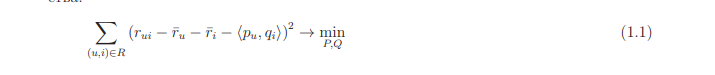

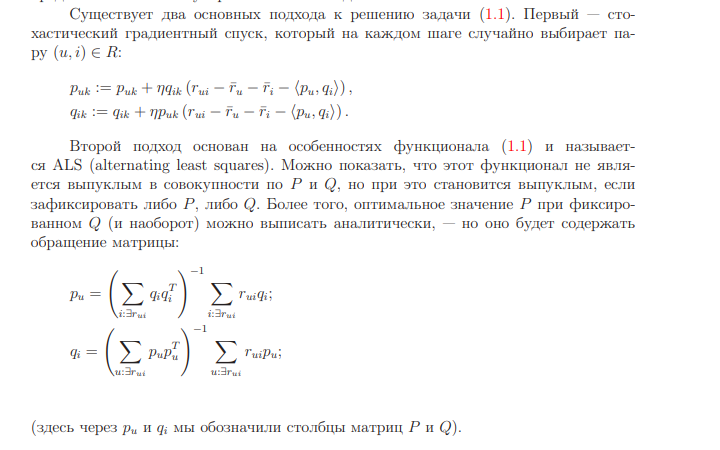

**SGD:**

Ответ


**ALS:**

Ответ


**Задание 7 (1.5 балла).** Реализуйте методы оптимизации параметров для обоих алгоритмов.

In [28]:
from numpy.random import default_rng

In [29]:
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd', lr = 0.0003, lamb= 0.01):
        super().__init__(ratings)
        self.dim = dim

        assert mode in ['sgd', 'als']
        self.mode = mode

        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = lr
        self.lamb = lamb

        # наблюдаемые взаимодействия (u, i, r)
        self.obs_u = self.ratings['userId'].to_numpy()
        self.obs_i = self.ratings['trackId'].to_numpy()
        # если столбца rating нет – считаем все r_ui = 1 (implicit feedback)
        self.obs_r = (self.ratings['rating'].to_numpy()
                      if 'rating' in self.ratings.columns
                      else np.ones(len(self.ratings), dtype=float))


    def fit(self, num_iters: int = 5):
      if self.mode == 'sgd':
          self._fit_sgd(num_iters)
      else:
          self._fit_als(num_iters)

    def _fit_sgd(self, num_iters: int):
        rng = default_rng()

        for epoch in tqdm(range(num_iters), desc='SGD  epochs'):
            order = rng.permutation(len(self.obs_u)) # рандомные перестановки на айди юзеров
            for j in order: # для каждого юзера j
                u, i, r_ui = self.obs_u[j], self.obs_i[j], self.obs_r[j]
                err = r_ui - self.P[u] @ self.Q[i]

                p_old = self.P[u].copy()
                self.P[u] += self.lr * (err * self.Q[i] - self.lamb * self.P[u])
                self.Q[i] += self.lr * (err * p_old     - self.lamb * self.Q[i])

    def _fit_als(self, num_iters: int):
        λI = self.lamb * np.eye(self.dim)
        items_by_user = self.ratings.groupby('userId')['trackId'].apply(list)
        users_by_item = self.ratings.groupby('trackId')['userId'].apply(list)

        for _ in tqdm(range(num_iters), desc='ALS epochs'):
            # шаг P
            for u, items in items_by_user.items():
                Q_i = self.Q[items] # |I_u| × d
                A   = Q_i.T @ Q_i + λI # d × d
                b   = Q_i.sum(axis=0) # implicit r_ui = 1
                self.P[u] = np.linalg.solve(A, b)

            # шаг Q
            for i, users in users_by_item.items():
                P_u = self.P[users] # |U_i| × d
                A   = P_u.T @ P_u + λI
                b   = P_u.sum(axis=0)
                self.Q[i] = np.linalg.solve(A, b)

    def recommend(self, uid: int, k: int | None = None):
        scores = self.P[uid] @ self.Q.T
        order  = np.argsort(-scores)
        return order if k is None else order[:k]

SGD (num_iters=5) - здесь все очень соу соу

SGD  epochs:   0%|          | 0/15 [00:00<?, ?it/s]

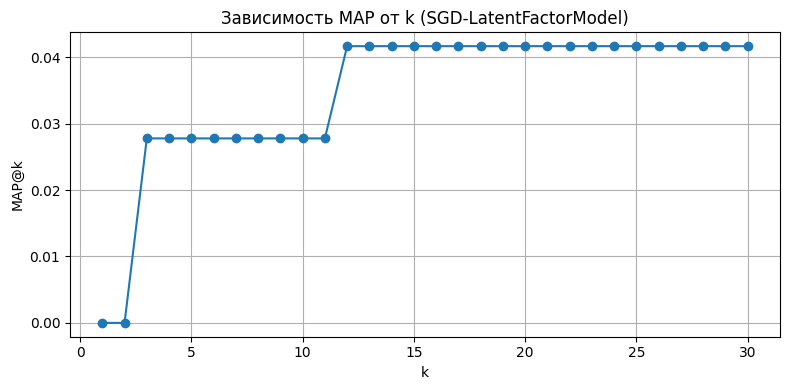

In [89]:
model_sgd = LatentFactorModel(ratings=train_ratings, dim=64, mode='sgd')
model_sgd.fit(num_iters=15)

K_MAX = 30
uids = test_ratings['userId'].unique()

pred_full = [model_sgd.recommend(u, k=K_MAX) for u in uids]
relevant  = [test_ratings[test_ratings['userId'] == u]['trackId'].tolist()
             for u in uids]

ks, map_scores = [], []
for k in range(1, K_MAX + 1):
    map_scores.append(mapk(relevant,
                           [pred[:k] for pred in pred_full], k))
    ks.append(k)

plt.figure(figsize=(8, 4))
plt.plot(ks, map_scores, marker='o')
plt.xlabel('k'); plt.ylabel('MAP@k')
plt.title('Зависимость MAP от k (SGD-LatentFactorModel)')
plt.grid(True); plt.tight_layout(); plt.show()

есть смысл несколько раз запустить, переодически до 0.04 будет мап вырастать на болих к (от 10-20)

ALS (num_iters=5) - норм

ALS epochs:   0%|          | 0/5 [00:00<?, ?it/s]

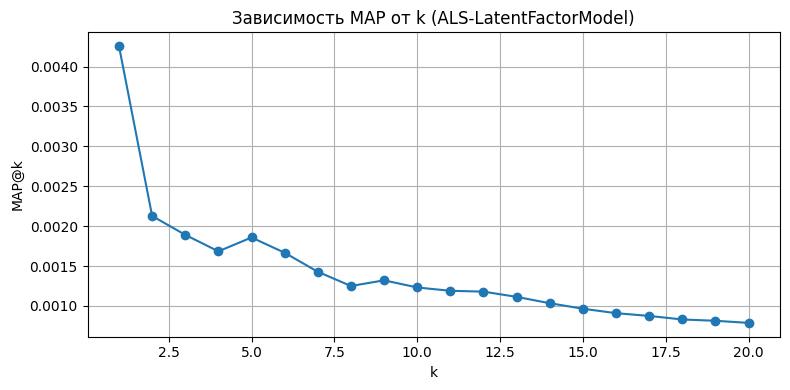

In [31]:
model_als = LatentFactorModel(ratings=train_ratings, dim=64, mode='als')
model_als.fit(num_iters=5)

K_MAX = 20
uids = test_ratings['userId'].unique()

pred_full = [model_als.recommend(u, k=K_MAX) for u in uids]
relevant  = [test_ratings[test_ratings['userId'] == u]['trackId'].tolist()
             for u in uids]

ks, map_scores = [], []
for k in range(1, K_MAX + 1):
    map_scores.append(mapk(relevant,
                           [pred[:k] for pred in pred_full], k))
    ks.append(k)

plt.figure(figsize=(8, 4))
plt.plot(ks, map_scores, marker='o')
plt.xlabel('k'); plt.ylabel('MAP@k')
plt.title('Зависимость MAP от k (ALS-LatentFactorModel)')
plt.grid(True); plt.tight_layout(); plt.show()


**Задание 8 (1 балл).** Для обоих алгоритмов подберите оптимальные значения размерности скрытого пространства $d$ и размера предсказания $k$. Как изменяется качество предсказаний с числом итераций обучения? Постройте соответствующие графики, сравните со случайным подхом и User2User, сделайте выводы. Какой алгоритм вам кажется более подходящим для данной задачи и почему?

__P. S.__ Хотя бы один из методов обучения должен приводить к лучшим результатам в сравнении с User2User подходом.

__P. P. S.__ Методу SGD свойственно переобучаться, поэтому при подборе параметров полезно смотреть на значения ошибки и оптимизируемой метрики на тренировочном датасете. Вы также можете менять начальную инициализацию и прочие параметры, за исключением архитектуры, на ваш вкус.

In [32]:
!pip install optuna

In [33]:
import optuna

Тут я хотела на батчах оценивать, но не успела переделать, можно кол-во запусков уменьшить или кол-во итераций снизить (хотя куда еще снижать), не то ждать минут 5-6 придется

Подбираем гиперпараметры для АЛС

In [36]:
def als_objective(trial):
    dim   = trial.suggest_int('dim', 32, 128)
    k     = trial.suggest_int('k', 5, 20)
    iters = trial.suggest_int('iters', 2, 5)
    lamb  = trial.suggest_float('lamb', 1e-3, 1e-1, log=True)

    model = LatentFactorModel(train_ratings, dim=dim, mode='als', lamb=lamb)
    model.fit(num_iters=iters)

    predicted = model.get_test_recommendations(k=k)
    return mapk(test_relevant, predicted, k)

In [37]:
study_als = optuna.create_study(direction='maximize',
                                pruner=optuna.pruners.MedianPruner())
study_als.optimize(als_objective, n_trials=5)

[I 2025-06-14 18:08:38,914] A new study created in memory with name: no-name-4d30e5f4-a8de-4423-8095-dfb97388bf07


ALS epochs:   0%|          | 0/4 [00:00<?, ?it/s]

[I 2025-06-14 18:09:50,816] Trial 0 finished with value: 0.0022364816691057823 and parameters: {'dim': 106, 'k': 9, 'iters': 4, 'lamb': 0.07212409096722673}. Best is trial 0 with value: 0.0022364816691057823.


ALS epochs:   0%|          | 0/2 [00:00<?, ?it/s]

[I 2025-06-14 18:10:10,423] Trial 1 finished with value: 0.0013576494427558255 and parameters: {'dim': 71, 'k': 7, 'iters': 2, 'lamb': 0.03556295849669228}. Best is trial 0 with value: 0.0022364816691057823.


...

[I 2025-06-14 18:10:41,430] Trial 2 finished with value: 0.0010333578950600228 and parameters: {'dim': 89, 'k': 16, 'iters': 3, 'lamb': 0.010633533859950209}. Best is trial 0 with value: 0.0022364816691057823.


ALS epochs:   0%|          | 0/5 [00:00<?, ?it/s]

[I 2025-06-14 18:12:12,456] Trial 3 finished with value: 0.0011144883485309015 and parameters: {'dim': 115, 'k': 7, 'iters': 5, 'lamb': 0.0013866171639017326}. Best is trial 0 with value: 0.0022364816691057823.


ALS epochs:   0%|          | 0/4 [00:00<?, ?it/s]

[I 2025-06-14 18:13:07,367] Trial 4 finished with value: 0.0020753883063913455 and parameters: {'dim': 91, 'k': 14, 'iters': 4, 'lamb': 0.0020160870653523717}. Best is trial 0 with value: 0.0022364816691057823.


Подбираем гиперпараметры для СГД

In [38]:
def sgd_objective(trial):
    dim   = trial.suggest_int('dim', 32, 128)
    k     = trial.suggest_int('k', 3, 20)
    iters = trial.suggest_int('iters', 3, 12)
    lr    = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    lamb  = trial.suggest_float('lamb', 1e-4, 1e-1, log=True)

    model = LatentFactorModel(train_ratings, dim=dim, mode='sgd', lr=lr, lamb=lamb)
    model.fit(num_iters=iters)

    predicted = model.get_test_recommendations(k=k)
    return mapk(test_relevant, predicted, k)

In [39]:
study_sgd = optuna.create_study(direction='maximize',
                                pruner=optuna.pruners.MedianPruner())
study_sgd.optimize(sgd_objective, n_trials=10)
# 10 на 5 в принципе можно поменять, быстрее будет

[I 2025-06-14 18:13:15,383] A new study created in memory with name: no-name-70d371cb-084d-4c47-927c-330b1811f4be


SGD  epochs:   0%|          | 0/11 [00:00<?, ?it/s]

[I 2025-06-14 18:13:43,198] Trial 0 finished with value: 3.546099290780142e-05 and parameters: {'dim': 54, 'k': 20, 'iters': 11, 'lr': 0.007510151593292731, 'lamb': 0.0007935338972592926}. Best is trial 0 with value: 3.546099290780142e-05.


SGD  epochs:   0%|          | 0/8 [00:00<?, ?it/s]

[I 2025-06-14 18:14:12,653] Trial 1 finished with value: 0.0 and parameters: {'dim': 102, 'k': 3, 'iters': 8, 'lr': 0.0003833547825427529, 'lamb': 0.0008995364744242417}. Best is trial 0 with value: 3.546099290780142e-05.


...

[I 2025-06-14 18:16:28,122] Trial 7 finished with value: 8.865248226950354e-05 and parameters: {'dim': 119, 'k': 14, 'iters': 11, 'lr': 0.0014459003954928288, 'lamb': 0.009844004699042546}. Best is trial 3 with value: 0.00035460992907801415.


SGD  epochs:   0%|          | 0/12 [00:00<?, ?it/s]

[I 2025-06-14 18:16:58,633] Trial 8 finished with value: 0.0 and parameters: {'dim': 92, 'k': 7, 'iters': 12, 'lr': 0.00038202062428757287, 'lamb': 0.0596152229205982}. Best is trial 3 with value: 0.00035460992907801415.


SGD  epochs:   0%|          | 0/4 [00:00<?, ?it/s]

[I 2025-06-14 18:17:09,393] Trial 9 finished with value: 0.0 and parameters: {'dim': 53, 'k': 6, 'iters': 4, 'lr': 0.00025620000253589054, 'lamb': 0.0011275819340020247}. Best is trial 3 with value: 0.00035460992907801415.


In [40]:
print('ALS best:', study_als.best_trial.params, study_als.best_value)
print('SGD best:', study_sgd.best_trial.params, study_sgd.best_value)

ALS best: {'dim': 106, 'k': 9, 'iters': 4, 'lamb': 0.07212409096722673} 0.0022364816691057823
SGD best: {'dim': 57, 'k': 12, 'iters': 7, 'lr': 0.0002765853738033099, 'lamb': 0.013429554606775305} 0.00035460992907801415


Если у вас получилось достаточно хорошее качество, то при оптимизации параметров марицы $Q$ похожим трекам стали соответствовать похожие векторы. Поэтому мы можем для любого трека найти наиболее близкие к нему в латентном пространстве и проверить степерь обученности модели вручную.

ALS: обучаем лучшую модель

In [41]:
d    = study_als.best_trial.params['dim']
k    = study_als.best_trial.params['k']
iters= study_als.best_trial.params['iters']
lamb = study_als.best_trial.params['lamb']

best_model_als = LatentFactorModel(train_ratings, mode='als', dim = d, lamb = lamb)
best_model_als.fit(num_iters = iters)

predicted = best_model_als.get_test_recommendations(k=k)
mapk_score = mapk(test_relevant, predicted, k=k)

print('ALS best:', study_als.best_trial.params, study_als.best_value)
print(f'MAP@{k} ALS = {mapk_score:.4f}')

ALS epochs:   0%|          | 0/4 [00:00<?, ?it/s]

ALS best: {'dim': 106, 'k': 9, 'iters': 4, 'lamb': 0.07212409096722673} 0.0022364816691057823
MAP@9 ALS = 0.0011


In [42]:
example_trackId = tracks_info[tracks_info.name == 'Где ты, где я'].iloc[0].id

preds = best_model_als.Q @ best_model_als.Q[example_trackId]
preds = preds / np.sqrt((best_model_als.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(best_model_als.Q[example_trackId])
similar_tracks

,name,artists,similarity
28313,"Где ты, где я",['Тимати'],1.000000
42316,Гучи,['Тимати'],0.784634
54056,"Бум, бум, бум",['VIU VIU'],0.784634
26036,Хочу Ещё,"['BIFFGUYZ', 'Bodya']",0.645130
27309,Умамы,['Потап и Настя'],0.638572
18625,Не сходи с ума,['Тимати'],0.635967
60295,#ПеретанцуйМеня,['Артур Пирожков'],0.632655
24232,Ты готов услышать нет?,"['Kristina Si', 'Natan']",0.602305
20979,Маршрутка,['IOWA'],0.594359
62690,УЛАЛАЛА,"['DONI', 'Зомб']",0.565286


Ищем треки, похожие на легендарную "Где ты, где я" от Тимати - видим песни исполнителей одного лейбла. По ходу не совсем небесполезную штуку написала

SGD: обучаем лучшую модель

In [43]:
d    = study_sgd.best_trial.params['dim']
k    = study_sgd.best_trial.params['k']
iters= study_sgd.best_trial.params['iters']
lr = study_sgd.best_trial.params['lr']
lamb = study_sgd.best_trial.params['lamb']

best_model_sgd = LatentFactorModel(train_ratings, mode='sgd', dim = d, lr = lr, lamb = lamb)
best_model_sgd.fit(num_iters = iters)

predicted = best_model_sgd.get_test_recommendations(k=k)

mapk_score = mapk(test_relevant, predicted, k=k)
print('SGD best:', study_sgd.best_trial.params, study_sgd.best_value)
print(f'MAP@{k} SGD = {mapk_score:.6f}')

SGD  epochs:   0%|          | 0/7 [00:00<?, ?it/s]

SGD best: {'dim': 57, 'k': 12, 'iters': 7, 'lr': 0.0002765853738033099, 'lamb': 0.013429554606775305} 0.00035460992907801415
MAP@12 SGD = 0.000355


In [44]:
example_trackId = tracks_info[tracks_info.name == 'Я бью женщин и детей'].iloc[0].id

preds = best_model_sgd.Q @ best_model_sgd.Q[example_trackId]
preds = preds / np.sqrt((best_model_sgd.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(best_model_sgd.Q[example_trackId])
similar_tracks

,name,artists,similarity
32561,Я бью женщин и детей,['Валентин Стрыкало'],1.000000
21619,Die by the Sword,['Slayer'],0.497905
37964,I Dont Wanna Know Her,"['timmies', 'Shiloh Dynasty']",0.493229
57516,My Neighbour TOTORO,"['Joe Hisaishi', 'London Symphony Orchestra']",0.482991
19756,Итоги,['Земфира'],0.474291
56073,Call Me,['plenka'],0.470621
12722,Ария угашенного принца,['Красная плесень'],0.452505
6478,Beggin',['Madcon'],0.451871
38075,Anywhere,['Rita Ora'],0.451345
35756,Мы не оставим города свои,['Декабрь'],0.448948


С англоязычными песнями вообще беда, на русских норм похожие раз через раз

**Бонус (1.5 балла).**

Постройте модель iALS и сравните ее качество с обучением ALS и SGD.

In [45]:
class LatentFactorModel(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd', lr=0.0003, lamb=0.01):
        super().__init__(ratings)
        self.dim = dim

        assert mode in ['sgd', 'als', 'ials']
        self.mode = mode

        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = lr
        self.lamb = lamb

        # наблюдаемые взаимодействия (u, i, r)
        self.obs_u = self.ratings['userId'].to_numpy()
        self.obs_i = self.ratings['trackId'].to_numpy()
        self.obs_r = (self.ratings['rating'].to_numpy()
                      if 'rating' in self.ratings.columns
                      else np.ones(len(self.ratings), dtype=float))

    def fit(self, num_iters: int = 5):
        if self.mode == 'sgd':
            self._fit_sgd(num_iters)
        elif self.mode == 'als':
            self._fit_als(num_iters)
        elif self.mode == 'ials':
            self._fit_ials(num_iters)

    def _fit_sgd(self, num_iters: int):
        rng = default_rng()
        for epoch in tqdm(range(num_iters), desc='SGD  epochs'):
            order = rng.permutation(len(self.obs_u))
            for j in order:
                u, i, r_ui = self.obs_u[j], self.obs_i[j], self.obs_r[j]
                err = r_ui - self.P[u] @ self.Q[i]

                p_old = self.P[u].copy()
                self.P[u] += self.lr * (err * self.Q[i] - self.lamb * self.P[u])
                self.Q[i] += self.lr * (err * p_old     - self.lamb * self.Q[i])

    def _fit_als(self, num_iters: int):
        λI = self.lamb * np.eye(self.dim)
        items_by_user = self.ratings.groupby('userId')['trackId'].apply(list)
        users_by_item = self.ratings.groupby('trackId')['userId'].apply(list)

        for _ in tqdm(range(num_iters), desc='ALS epochs'):
            for u, items in items_by_user.items():
                Q_i = self.Q[items]
                A = Q_i.T @ Q_i + λI
                b = Q_i.sum(axis=0)
                self.P[u] = np.linalg.solve(A, b)

            for i, users in users_by_item.items():
                P_u = self.P[users]
                A = P_u.T @ P_u + λI
                b = P_u.sum(axis=0)
                self.Q[i] = np.linalg.solve(A, b)

    def _fit_ials(self, num_iters: int = 5):
        λI = self.lamb * np.eye(self.dim)

        for _ in tqdm(range(num_iters), desc='iALS epochs'):
            qtq = self.Q.T @ self.Q                      # QᵀQ
            for u in range(self.n_users):
                idx = np.where(self.R[u] > 0)[0]         # I_u
                if idx.size == 0:
                    continue
                Q_i = self.Q[idx]
                A = Q_i.T @ Q_i + λI + qtq
                b = Q_i.sum(axis=0)
                self.P[u] = np.linalg.solve(A, b)

            ptp = self.P.T @ self.P                      # PᵀP
            for i in range(self.n_items):
                idx = np.where(self.R[:, i] > 0)[0]      # U_i
                if idx.size == 0:
                    continue
                P_u = self.P[idx]
                A = P_u.T @ P_u + λI + ptp
                b = P_u.sum(axis=0)
                self.Q[i] = np.linalg.solve(A, b)


    def recommend(self, uid: int, k: int | None = None):
        scores = self.P[uid] @ self.Q.T
        order = np.argsort(-scores)
        return order if k is None else order[:k]


ALS: подбор гиперпараметров

In [46]:
def ials_objective(trial):
    dim   = trial.suggest_int('dim', 32, 128)
    k     = trial.suggest_int('k', 3, 20)
    iters = trial.suggest_int('iters', 1, 5)
    lamb  = trial.suggest_float('lamb', 1e-4, 1e-1, log=True)

    model = LatentFactorModel(train_ratings, dim=dim, mode='ials', lamb=lamb)
    model.fit(num_iters=iters)

    predicted = model.get_test_recommendations(k=k)
    return mapk(test_relevant, predicted, k)

In [47]:
study_ials = optuna.create_study(direction='maximize',
                                pruner=optuna.pruners.MedianPruner())
study_ials.optimize(ials_objective, n_trials=5)

[I 2025-06-14 18:18:33,792] A new study created in memory with name: no-name-0de82832-24e5-483e-a2ba-56d567ee3c49


iALS epochs:   0%|          | 0/2 [00:00<?, ?it/s]

[I 2025-06-14 18:18:49,543] Trial 0 finished with value: 0.0005774982531766462 and parameters: {'dim': 44, 'k': 19, 'iters': 2, 'lamb': 0.006404601845538683}. Best is trial 0 with value: 0.0005774982531766462.


iALS epochs:   0%|          | 0/3 [00:00<?, ?it/s]

[I 2025-06-14 18:19:14,907] Trial 1 finished with value: 0.0015011820330969267 and parameters: {'dim': 56, 'k': 6, 'iters': 3, 'lamb': 0.00014907038392361426}. Best is trial 1 with value: 0.0015011820330969267.


...

[I 2025-06-14 18:19:30,061] Trial 2 finished with value: 0.0007977785282749822 and parameters: {'dim': 79, 'k': 9, 'iters': 1, 'lamb': 0.00011863988550341885}. Best is trial 1 with value: 0.0015011820330969267.


iALS epochs:   0%|          | 0/1 [00:00<?, ?it/s]

[I 2025-06-14 18:19:56,289] Trial 3 finished with value: 0.0012306524884747663 and parameters: {'dim': 124, 'k': 18, 'iters': 1, 'lamb': 0.005416767772865663}. Best is trial 1 with value: 0.0015011820330969267.


iALS epochs:   0%|          | 0/4 [00:00<?, ?it/s]

[I 2025-06-14 18:20:26,139] Trial 4 finished with value: 0.0008274231678486998 and parameters: {'dim': 52, 'k': 6, 'iters': 4, 'lamb': 0.017151134241978318}. Best is trial 1 with value: 0.0015011820330969267.


In [48]:
print('ALS best:', study_als.best_trial.params, study_als.best_value)
print('SGD best:', study_sgd.best_trial.params, study_sgd.best_value)
print('iALS best:', study_ials.best_trial.params, study_ials.best_value)

ALS best: {'dim': 106, 'k': 9, 'iters': 4, 'lamb': 0.07212409096722673} 0.0022364816691057823
SGD best: {'dim': 57, 'k': 12, 'iters': 7, 'lr': 0.0002765853738033099, 'lamb': 0.013429554606775305} 0.00035460992907801415
iALS best: {'dim': 56, 'k': 6, 'iters': 3, 'lamb': 0.00014907038392361426} 0.0015011820330969267


ALS: обучаем лучшую модель

In [49]:
d    = study_ials.best_trial.params['dim']
k    = study_ials.best_trial.params['k']
iters= study_ials.best_trial.params['iters']
lamb = study_ials.best_trial.params['lamb']

best_model_ials = LatentFactorModel(train_ratings, mode='ials', dim = d, lamb = lamb)
best_model_ials.fit(num_iters = iters)

iALS epochs:   0%|          | 0/3 [00:00<?, ?it/s]

In [50]:
predicted = best_model_ials.get_test_recommendations(k=k)
mapk_score = mapk(test_relevant, predicted, k=k)
print('iALS best:', study_ials.best_trial.params, study_ials.best_value)
print(f'MAP@{k} iALS = {mapk_score:.6f}')

iALS best: {'dim': 56, 'k': 6, 'iters': 3, 'lamb': 0.00014907038392361426} 0.0015011820330969267
MAP@6 iALS = 0.004811


In [51]:
example_trackId = tracks_info[tracks_info.name == 'Бэйби'].iloc[0].id

preds = best_model_ials.Q @ best_model_ials.Q[example_trackId]
preds = preds / np.sqrt((best_model_ials.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(best_model_ials.Q[example_trackId])
similar_tracks

,name,artists,similarity
40655,Бэйби,['ЛСП'],1.000000
31069,Неон,"['ЛСП', 'PHARAOH']",0.963218
35059,Ещё один день,['ЛСП'],0.928439
25305,Хиппи,['ЛСП'],0.928439
24936,ОК,['ЛСП'],0.900680
24940,Что-то ещё,['ЛСП'],0.887123
31064,Порнозвезда,"['ЛСП', 'PHARAOH']",0.861591
38318,Я женюсь на девочке из аниме,['ЕГОР НАТС'],0.850025
42296,Твоё имя,['Монеточка'],0.850025
41570,После восхода,['May Wave$'],0.850025


Кайф, хоть тут нормально выстрелило

### Часть 3. Второй уровень рекомендаций.

Выше мы построили простейшие модели, которые показывают не слишком высокое качество, но зато работают очень быстро. Воспользуемся ими для того, чтобы отобрать некоторое количество наиболее перспективных треков, которые мы сможем отранжировать уже более сложной моделью (в нашем случае это будет [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboost)).

**Задание 9 (1 балл).**

Для каждого пользователя возьмите топ-100 рекомендованных треков от модели LFM (ALS или SGD на ваш выбор) и топ-100 от модели User2User. Это будут наши кандидаты, которые мы затем будем ранжировать бустингом.

In [58]:
k = 100
lfm_recs = best_model_ials.get_test_recommendations(k)
u2u_recs = user2user.get_test_recommendations(k)

In [59]:
lfm_recs.shape, u2u_recs.shape

((235, 100), (235, 100))

In [60]:
lfm_recs

array([[25280,  2799, 13222, ...,  9675, 13694,  7535],
       [40209,  6231, 18914, ..., 42183, 34063, 41617],
       [ 1073,  1019,  1056, ...,   384,  7598, 11133],
       ...,
       [ 1019,  8263,  9438, ...,  5517, 24005,  5520],
       [  805,  7533,   164, ...,  3825,  2194,  5848],
       [49679, 30518, 57847, ..., 31888, 52105,  8568]])

**Задание 10 (2 балла).**

Подготовьте датасет для обучения модели ранжирования. Он должен состоять из пар: объект, целевая переменная. Объект - это пара (user, item) и всякие дополнительные признаки на их основе. Предлагается создать набор следущих признаков, однако вы можете добавлять свои по желанию, если они вам кажутся разумными:
 1) id пользователя
 1) id трека
 1) косинусное расстояние между эмбеддингами LFM соответствующих пользователя и трека
 1) среднее значение меры Жаккара между этим пользователем и остальными из User2User модели
 1) доля пользователей, слушавших этот трек (взять из обучающей выборки в Части 1)
 1) количество прослушанных пользователем треков (взять из обучающей выборки в Части 1)

В качестве целевой переменной возьмем бинарную метку "попал ли трек в 50 последних прослушанных пользователем"

Разбейте полученную выборку на обучающую и тестовую в отношении 3:2 так, чтобы пропорции положительных и отрицательных примеров в обоих подвыборках были одинаковыми.

In [61]:
P, Q = best_model_ials.P, best_model_ials.Q
p_norm = np.linalg.norm(P, axis=1) + 1e-9          # ‖P‖
q_norm = np.linalg.norm(Q, axis=1) + 1e-9          # ‖Q‖

popularity = best_model_ials.R.mean(axis=0)
user_counts = best_model_ials.R.sum(axis=1)
avg_jaccard = user2user.sims

rows = []

for ui, u in enumerate(test_users):
    cand = np.unique(np.concatenate([lfm_recs[ui], u2u_recs[ui]]))
    for i in cand:
        cos = (P[u] @ Q[i]) / (p_norm[u] * q_norm[i])
        rows.append({
            "user_id": u,
            "track_id": int(i),
            "cosine_distance": cos,
            "avg_jaccard_user2user": float(avg_jaccard[u]),
            "track_listen_ratio": float(popularity[i]),
            "user_track_count": int(user_counts[u]),
            "in_last_50": int(i in test_relevant[ui])
        })

df = pd.DataFrame(rows, columns=[
    "user_id", "track_id", "cosine_distance",
    "avg_jaccard_user2user", "track_listen_ratio",
    "user_track_count", "in_last_50"
])


In [62]:
df.head(3)

,user_id,track_id,cosine_distance,avg_jaccard_user2user,track_listen_ratio,user_track_count,in_last_50
0,0,23,0.280913,0.001603,0.037344,206,0
1,0,81,0.265213,0.001603,0.049793,206,0
2,0,94,0.183241,0.001603,0.029046,206,0


In [73]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=2/5, random_state=42, stratify=df['in_last_50'])

train = train.sort_values('user_id').reset_index(drop=True)
test  = test.sort_values('user_id').reset_index(drop=True)

y_train = train.pop('in_last_50')
y_test  = test.pop('in_last_50')

X_train_f = train.drop(columns='user_id')
X_test_f  = test.drop(columns='user_id')

# Список релевантных треков для MAP@20
relevant = (
    test.assign(target=y_test)
        .query('target == 1')
        .groupby('user_id')['track_id']
        .apply(list)
        .reindex(sorted(test['user_id'].unique()), fill_value=[])
        .tolist()
)

Как уже было сказано, для построения ранжирующей модели мы будем пользоваться библиотекой [CatBoost](https://www.youtube.com/watch?v=dQw4w9WgXcQ).

Для преобразования датасета в удобный вид полезно использовать метод [`Pool`](https://catboost.ai/en/docs/concepts/python-reference_pool).

In [66]:
!pip install catboost

In [67]:
import catboost
g_train = train['user_id']
g_test  = test ['user_id']

train_pool = catboost.Pool(X_train_f, y_train, group_id=g_train)
test_pool  = catboost.Pool(X_test_f,  y_test,  group_id=g_test)

**Задание 11 (1 балл)**

Обучите `CatBoostClassifier`. С его помощью сделайте предсказания для тестовой выборки и посчитайте MAP@20. Сравните с рекомендациями моделей User2User и LFM. Учтите, что для честного сравнения необходимо пересчитать предсказания моделей на нашей новой тестовой выборке. Получилось ли улучшить результаты?

In [75]:
from catboost import CatBoostClassifier
from catboost import CatBoostRanker

clf = CatBoostClassifier(
        verbose=100
)
clf.fit(train_pool)
probs = clf.predict_proba(test_pool)[:, 1]

pred_df = pd.DataFrame({
        "user_id": test["user_id"],
        "track_id": test["track_id"],
        "p": probs
})

top20 = (pred_df
         .sort_values(['user_id', 'p'], ascending=[True, False])
         .groupby('user_id')
         .head(20))

test_preds = (top20.groupby('user_id')['track_id']
                     .apply(list)
                     .tolist())

# test_relevant – список реальных треков из last-50 для тех же user_id
MAP20_cat = mapk(test_relevant, test_preds, k=20)
print(f"CatBoostClassifier  MAP@20 = {MAP20_cat:.4f}")

Learning rate set to 0.04017
0:	learn: 0.5951048	total: 9.63ms	remaining: 9.62s
100:	learn: 0.0251209	total: 1.26s	remaining: 11.2s
200:	learn: 0.0211854	total: 3.21s	remaining: 12.7s
300:	learn: 0.0184957	total: 4.53s	remaining: 10.5s
400:	learn: 0.0164169	total: 5.27s	remaining: 7.87s
500:	learn: 0.0146593	total: 6.01s	remaining: 5.99s
600:	learn: 0.0131542	total: 8.22s	remaining: 5.46s
700:	learn: 0.0119152	total: 8.95s	remaining: 3.82s
800:	learn: 0.0107465	total: 9.69s	remaining: 2.41s
900:	learn: 0.0097463	total: 10.4s	remaining: 1.15s
999:	learn: 0.0088796	total: 11.2s	remaining: 0us
CatBoostClassifier  MAP@20 = 0.0066


ALS

In [76]:
# 1. берём пары (user_id, track_id) из CatBoost-сплита
cat_cols = ['user_id', 'track_id']      # из train / test
rat_cols = ['userId',  'trackId']       # из исходного ratings

train_pairs = train[cat_cols]
test_pairs  = test [cat_cols]

# 2. мёрджим по соответствующим колонкам
train_ratings = ratings.merge(train_pairs,
                              left_on=rat_cols, right_on=cat_cols, how='inner')
test_ratings  = ratings.merge(test_pairs,
                              left_on=rat_cols, right_on=cat_cols, how='inner')

# 3. оставляем только нужные столбцы из ratings
train_ratings = train_ratings[rat_cols]
test_ratings  = test_ratings [rat_cols]


In [77]:
# 4. переиндексируем, чтобы id шли 0…N-1
train_ratings['userId'], u_enc = pd.factorize(train_ratings['userId'])
train_ratings['trackId'], i_enc = pd.factorize(train_ratings['trackId'])

test_ratings = test_ratings[
    test_ratings['userId'].isin(u_enc) &
    test_ratings['trackId'].isin(i_enc)
].copy()

test_ratings['userId']  = test_ratings['userId'].map(dict(zip(u_enc, range(len(u_enc)))))
test_ratings['trackId'] = test_ratings['trackId'].map(dict(zip(i_enc, range(len(i_enc)))))

# 5. списки для MAP@20
test_users    = np.sort(test_ratings['userId'].unique())
test_relevant = (test_ratings.groupby('userId')['trackId']
                 .apply(list).reindex(test_users, fill_value=[])
                 .tolist())


In [78]:
model_als = LatentFactorModel(train_ratings, mode='als', dim=d, lamb=lamb)
model_als.fit(num_iters=iters)

als_preds = model_als.get_test_recommendations(k=20)
map20_als = mapk(test_relevant, als_preds)
print(f'MAP@20 ALS = {map20_als:.4f}')

ALS epochs:   0%|          | 0/3 [00:00<?, ?it/s]

MAP@20 ALS = 0.0119


U2U

In [79]:
model_u2u = User2User(train_ratings)
als_preds = model_u2u.get_test_recommendations(k=20)
map20_u2u = mapk(test_relevant, als_preds)
print(f'MAP@20 U2U = {map20_u2u:.4f}')

MAP@20 U2U = 0.0282


**Задание 12 (1 балл)**

Обучите `CatBoostRanker`, выбрав подходящую функцию ранжирования из тех, которые были рассмотрены на лекции. Проделайте все те же действия, что и с `CatBoostClassifier` и сравните результаты.

In [81]:
ranker = CatBoostRanker(
        iterations = 600,
        loss_function='YetiRank',
        random_seed=42,
        verbose=100
)
ranker.fit(train_pool, eval_set=test_pool)

scores = ranker.predict(test_pool)

pred_df = pd.DataFrame({
        'user_id' : test['user_id'],
        'track_id': test['track_id'],
        'score'   : scores
})

top20_ranker = (pred_df
                .sort_values(['user_id', 'score'], ascending=[True, False])
                .groupby('user_id')
                .head(20))

ranker_preds = (top20_ranker
                .groupby('user_id')['track_id']
                .apply(list)
                .tolist())

MAP20_ranker = mapk(relevant, ranker_preds, k=20)

0:	test: 0.0586015	best: 0.0586015 (0)	total: 45ms	remaining: 27s
100:	test: 0.1584610	best: 0.1608169 (83)	total: 6.72s	remaining: 33.2s
200:	test: 0.1572818	best: 0.1621019 (134)	total: 11.2s	remaining: 22.3s
300:	test: 0.1592558	best: 0.1621019 (134)	total: 17.2s	remaining: 17.1s
400:	test: 0.1597026	best: 0.1621019 (134)	total: 21.7s	remaining: 10.8s
500:	test: 0.1599947	best: 0.1621019 (134)	total: 28s	remaining: 5.53s
599:	test: 0.1580126	best: 0.1621019 (134)	total: 34.2s	remaining: 0us

bestTest = 0.1621018787
bestIteration = 134

Shrink model to first 135 iterations.


In [83]:
MAP20_ranker

np.float64(nan)

In [82]:
print(f"CatBoostRanker  MAP@20 = {MAP20_ranker:.4f}")
print(f"CatBoostClassifier MAP@20 = {MAP20_cat:.4f}")
print(f'MAP@20 ALS = {map20_als:.4f}')
print(f'MAP@20 U2U = {map20_u2u:.4f}')

CatBoostRanker  MAP@20 = nan
CatBoostClassifier MAP@20 = 0.0066
MAP@20 ALS = 0.0119
MAP@20 U2U = 0.0282
